In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
passing_data = pd.read_csv("Ohio State Passing Stats.csv")

In [3]:
passing_data

,Rk,Player,Yrs,From,To,G,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,Y/A,AY/A,Y/C,Y/G,Rate,Player-additional
0,1,J.T. Barrett*,4,2014,2017,50,769,1211,63.5,9434,104,8.6,30,2.5,7.8,8.39,12.3,188.7,152.3,jt-barrett-1
1,2,C.J. Stroud*,3,2020,2022,25,575,830,69.3,8123,85,10.2,12,1.4,9.8,11.18,14.1,324.9,182.4,cj-stroud-1
2,3,Bobby Hoying,4,1992,1995,42,463,782,59.2,6751,54,6.9,33,4.2,8.6,8.12,14.6,160.7,146.1,bobby-hoying-1
3,4,Art Schlichter,4,1978,1981,44,439,849,51.7,6584,44,5.2,42,4.9,7.8,6.57,15.0,149.6,124.1,art-schlichter-1
4,5,Terrelle Pryor*,3,2008,2010,39,477,783,60.9,6177,57,7.3,26,3.3,7.9,7.85,12.9,158.4,144.6,terrelle-pryor-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,169,B.J. Sander,4,1999,2003,11,0,1,0.0,0,0,0.0,0,0.0,0.0,0.00,NaN,0.0,0.0,bj-sander-1
169,170,Chris Vance,2,2001,2002,11,0,1,0.0,0,0,0.0,0,0.0,0.0,0.00,NaN,0.0,0.0,chris-vance-1
170,171,Cameron Johnston*,4,2013,2016,13,0,1,0.0,0,0,0.0,0,0.0,0.0,0.00,NaN,0.0,0.0,cameron-johnston-1
171,172,Jalin Marshall*,2,2014,2015,15,0,2,0.0,0,0,0.0,0,0.0,0.0,0.00,NaN,0.0,0.0,jalin-marshall-1


In [4]:
passing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 173 non-null    int64  
 1   Player             173 non-null    object 
 2   Yrs                173 non-null    int64  
 3   From               173 non-null    int64  
 4   To                 173 non-null    int64  
 5   G                  173 non-null    int64  
 6   Cmp                173 non-null    int64  
 7   Att                173 non-null    int64  
 8   Cmp%               173 non-null    float64
 9   Yds                173 non-null    int64  
 10  TD                 173 non-null    int64  
 11  TD%                173 non-null    float64
 12  Int                173 non-null    int64  
 13  Int%               173 non-null    float64
 14  Y/A                173 non-null    float64
 15  AY/A               173 non-null    float64
 16  Y/C                146 non

# QUESTION 2

Note: Graphs and tables will appear different from those in final report. Refer to those graphs and tables. K-Nearest Neighbors yields different results every time you do it.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
#This is for the data columns that dont need any formatting done to them. I am trying to get the machine to predict the Yrs a player has played based
##on the numbers of touchdowns and completions they have thrown
y = passing_data ["Yrs"]
x = passing_data[["TD", "Cmp"]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [7]:
x_train

,TD,Cmp
74,0,7
37,16,89
30,8,76
72,0,18
20,17,175
...,...,...
123,0,2
108,0,3
5,36,417
86,1,5


In [8]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [9]:
predictions = knn.predict(x_test)

In [10]:
print(predictions)

[3 1 1 2 3 2 3 1 1 1 1 1 2 1 1 3 3 1 2 1 2 3 1 3 4 3 3 1 4 1 1 1 1 1 1]


In [11]:
accuracy = accuracy_score(predictions, y_test)
print(accuracy*100)
##Accuracy score is very low and could be improved by increasing the number of neighbors

37.142857142857146


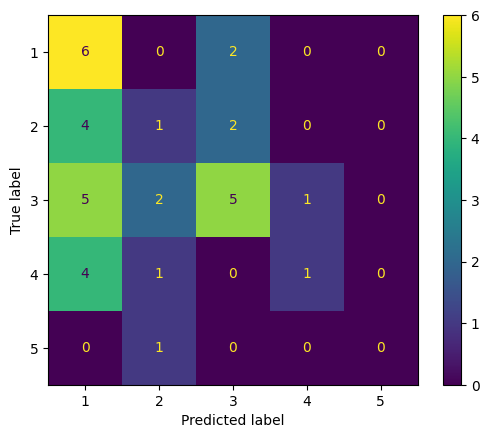

In [12]:
ConfusionMatrixDisplay.from_estimator(knn, x_test, y_test)
##Machine rarely made correct predictions

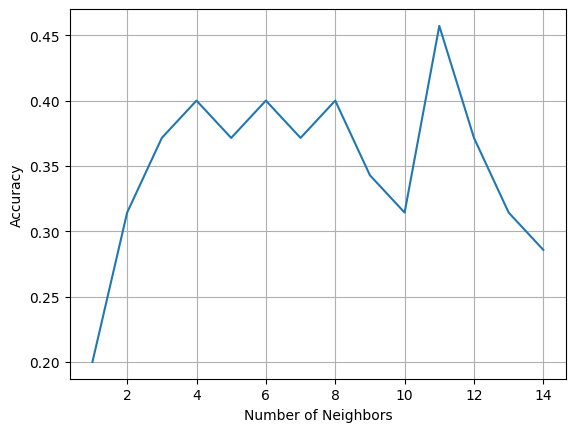

In [13]:
##Used Hyperparamater Tuning to determine the optimal number of neighbors.
k_values = []
accuracies = []
for k in range(1,15,1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    predictions = knn.predict(x_test)
    accuracy = accuracy_score(predictions, y_test)
    k_values.append(k)
    accuracies.append(accuracy)

plt.plot(k_values, accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.grid()

In [14]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [15]:
predictions = knn.predict(x_test)

In [16]:
print(predictions)

[3 4 2 3 4 3 2 1 3 1 4 1 3 1 1 3 2 1 2 3 4 3 3 3 3 3 2 1 4 1 1 1 1 1 4]


In [17]:
accuracy = accuracy_score(predictions, y_test)
print(accuracy*100)
##Substantial increase in accuracy by increasing neighbors from 3 to 7

37.142857142857146


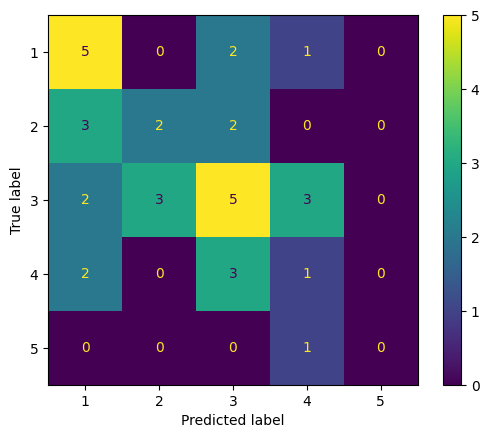

In [18]:
ConfusionMatrixDisplay.from_estimator(knn, x_test, y_test)
##Machine predicted mostly 2 year players and 4 year players the most accurately

# QUESTION 3

Text(0, 0.5, 'Passer Rating')

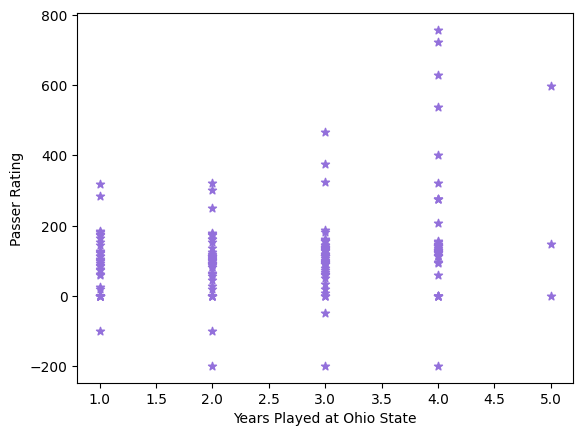

In [19]:
year = passing_data["Yrs"]
pass_rating = passing_data["Rate"]
plt.scatter(year, pass_rating, color = "mediumpurple", marker = "*")
plt.xlabel("Years Played at Ohio State")
plt.ylabel("Passer Rating")

In [23]:
corr2 = scipy.stats.pearsonr(year, pass_rating)
correlation_score2 = corr2[0]
print ("The correlation score is:", correlation_score2)

The correlation score is: 0.2650591889068094


In [24]:
linear_model2 = scipy.stats.linregress(year, pass_rating)
print(linear_model2)

LinregressResult(slope=np.float64(31.371753757664553), intercept=np.float64(38.518308101361995), rvalue=np.float64(0.2650591889068095), pvalue=np.float64(0.00042462699178528985), stderr=np.float64(8.727291509748147), intercept_stderr=np.float64(24.77352565936754))


In [25]:
slope2 = 31.371753757664553
print(slope2)

31.371753757664553


In [26]:
intercept2 = 38.518308101361995
print(intercept2)

38.518308101361995


In [27]:
linear_fit2 = slope2 * year + intercept2

Text(0, 0.5, 'Passer Rating')

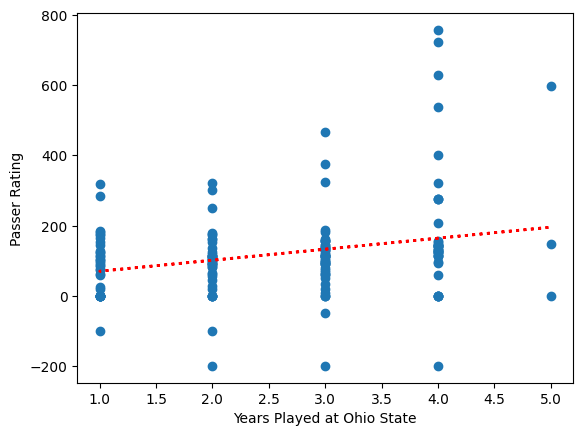

In [28]:
plt.scatter(year, pass_rating)
plt.plot(year, linear_fit2, color="red", linewidth = 2, linestyle=":")
plt.xlabel("Years Played at Ohio State")
plt.ylabel("Passer Rating")

In [29]:
#According to the graph, the longer you play at Ohio State, your Passer Rating does go up, meaning there is a positive linear relationship 
#between the amount of years played at Ohio State and the overall passer rating of the player.